# BREAST CANCER CLASSIFICATION PROJECT WITH Neural Network:

## Import dependencies:

In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

## Data Collection & Processing:

In [261]:
# Load the dataset:
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [262]:
breast_cancer_dataset

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [263]:
# load the dataset into a dataframe:
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns=breast_cancer_dataset.feature_names)

In [264]:
#load first few rows of the data:
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [265]:
# adding the target column to the dataframe:
data_frame["label"] = breast_cancer_dataset.target

In [266]:
#load last few rows of the dataset:
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [267]:
#shape of the dataset (no. of rows X no. of columns):
data_frame.shape

(569, 31)

In [268]:
#getting some information about the data:
data_frame.info()

print("\n\n\n")

data_frame.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [269]:
# checking for any missing values:
data_frame.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

In [270]:
# checking for any duplicate values:
data_frame.duplicated().sum()

np.int64(0)

In [271]:
# checking the distribution of the target variable:
data_frame["label"].value_counts().reset_index(name="Frequency (1=Benign , 0=Malignant)")

,label,"Frequency (1=Benign , 0=Malignant)"
0,1,357
1,0,212


In [272]:
data_frame.groupby("label").mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [273]:
#Seperating the features and the target:
X = data_frame.drop(columns="label",axis=1)
Y = data_frame["label"]

X_train , X_test, Y_train, Y_test = train_test_split(X, Y,random_state=2, test_size=0.2)

In [274]:
#standardize the data:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


## Building the Neural Network:

In [275]:
#Import tensorflow and keras for building this neural-network:
import tensorflow as tf
tf.random.set_seed(3) #for getting same accuracy (no matter how many times we run our project)

from tensorflow import keras

In [276]:
# build the input layer, hidden layer and output layer:

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)), #passing 30 dimensions in the input layer
    keras.layers.Dense(20,activation="relu"), #20 neurons in the hidden layer with relu activation function
    keras.layers.Dense(2,activation="sigmoid"), #2 (complsourily 2 classes which we want to predict) neurons in the output layer with sigmoid activation function
])

In [277]:
#compile this neural-network with some factors:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [278]:
#training the neural network model:
history = model.fit(X_train_std,Y_train,validation_split=0.1,epochs=10) #epochs means how many times your model goes through the data


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3594 - loss: 0.8768 - val_accuracy: 0.4565 - val_loss: 0.7400
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6064 - loss: 0.6153 - val_accuracy: 0.7609 - val_loss: 0.5107
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8313 - loss: 0.4535 - val_accuracy: 0.8913 - val_loss: 0.3723
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8998 - loss: 0.3552 - val_accuracy: 0.9130 - val_loss: 0.2927
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9169 - loss: 0.2916 - val_accuracy: 0.9130 - val_loss: 0.2426
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9218 - loss: 0.2475 - val_accuracy: 0.9348 - val_loss: 0.2090
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9315 - loss: 0.2151 - val_accuracy: 0.9130 - val_loss: 0.1855
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9413 - loss: 0.1905 - val_accuracy: 0.9348 - v

## Visualizing the accuracy and the loss:

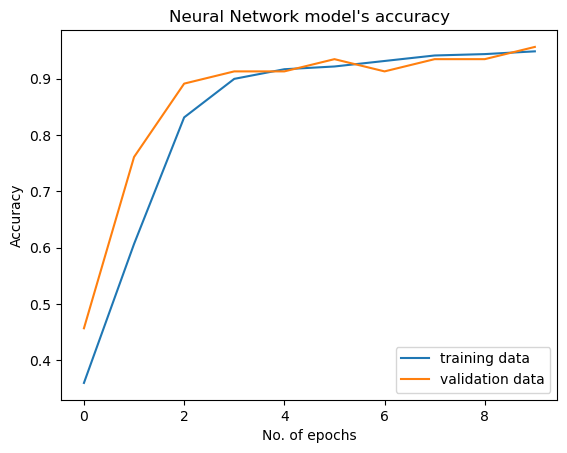

In [279]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Neural Network model's accuracy")
plt.ylabel("Accuracy")
plt.xlabel("No. of epochs")

plt.legend(["training data","validation data"],loc = "lower right")


plt.show()

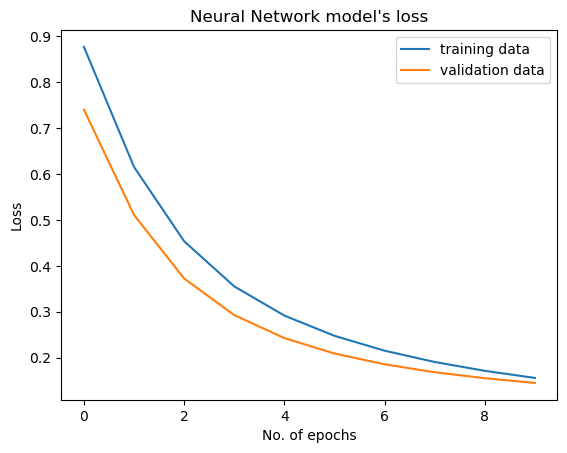

In [280]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Neural Network model's loss")
plt.ylabel("Loss")
plt.xlabel("No. of epochs")

plt.legend(["training data","validation data"],loc = "upper right")


plt.show()

## Test the neural network on the test-data:

In [281]:
loss , accuracy = model.evaluate(X_test_std , Y_test)

print("Accuracy = ",accuracy)
print("Loss = ",loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9649 - loss: 0.1388
Accuracy =  0.9649122953414917
Loss =  0.13883017003536224


## Build a predictive system (on this model): [different from tranditional ML]

In [282]:
Y_pred = model.predict(X_test_std)
print(Y_pred.shape)
print(Y_pred[0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
(114, 2)
[0.23746747 0.748823  ]


### Now convert the numerical columns into labels:

In [283]:
print("Probability of being Malignant \t\t Probability of being Benign \tInsights")
for i in range(len(Y_pred)):
    if(Y_pred[i,0] > Y_pred[i,1]):
        print(Y_pred[i,0],"\t\t\t\t",Y_pred[i,1],"\t\t\t\tperson has malignant tumor")
    elif(Y_pred[i,1] > Y_pred[i,0]):
        print(Y_pred[i,0],"\t\t\t\t",Y_pred[i,1],"\t\t\t\tperson has benign tumor")

Probability of being Malignant 		 Probability of being Benign 	Insights
0.23746747 				 0.748823 				person has benign tumor
0.4848071 				 0.58124286 				person has benign tumor
0.061762154 				 0.9228177 				person has benign tumor
0.96736604 				 0.0017867999 				person has malignant tumor
0.45096898 				 0.49671373 				person has benign tumor
0.8976398 				 0.061367217 				person has malignant tumor
0.25677705 				 0.7045574 				person has benign tumor
0.19432537 				 0.8887907 				person has benign tumor
0.2787923 				 0.83322227 				person has benign tumor
0.23887411 				 0.7817191 				person has benign tumor
0.41409734 				 0.5525281 				person has benign tumor
0.21220595 				 0.7568832 				person has benign tumor
0.18050414 				 0.73961306 				person has benign tumor
0.26232108 				 0.79197913 				person has benign tumor
0.14779803 				 0.8662349 				person has benign tumor
0.749877 				 0.2016621 				person has malignant tumor
0.11304479 				 0.8569514 				person has benign tu

In [284]:
Y_pred_labels = [np.argmax(i) for i in Y_pred]
for i in Y_pred_labels:
    if i==0:
        print("Malignant",end="\t")
    elif i==1:
        print("Benign",end="\t")

Benign	Benign	Benign	Malignant	Benign	Malignant	Benign	Benign	Benign	Benign	Benign	Benign	Benign	Benign	Benign	Malignant	Benign	Benign	Benign	Malignant	Benign	Benign	Benign	Benign	Benign	Malignant	Benign	Benign	Malignant	Malignant	Benign	Benign	Benign	Malignant	Malignant	Benign	Benign	Benign	Benign	Benign	Malignant	Malignant	Benign	Benign	Malignant	Benign	Benign	Benign	Malignant	Malignant	Benign	Malignant	Benign	Benign	Benign	Benign	Benign	Benign	Malignant	Benign	Benign	Malignant	Benign	Malignant	Malignant	Benign	Malignant	Malignant	Benign	Malignant	Malignant	Malignant	Benign	Malignant	Benign	Malignant	Benign	Benign	Benign	Malignant	Malignant	Malignant	Malignant	Benign	Benign	Benign	Benign	Benign	Benign	Malignant	Benign	Benign	Benign	Malignant	Malignant	Benign	Malignant	Malignant	Benign	Benign	Benign	Malignant	Malignant	Malignant	Benign	Benign	Benign	Benign	Benign	Benign	Malignant	Malignant	Benign	Malignant	

## Building the predictive system:

In [285]:
input_data = (17.99,10.38,	122.8,	1001	,0.1184	,0.2776,	0.3001,	0.1471,	0.2419,	0.07871,	1.095	,0.9053	,8.589	,153.4,	0.006399,	0.04904	,0.05373,	0.01587,	0.03003,	0.006193	,25.38,	17.33	,184.6	,2019,	0.1622	,0.6656,	0.7119	,0.2654,	0.4601	,0.1189
)

#change the input-data to a numpy array:
input_data_as_numpy_array = np.asarray(input_data)

#reshape the numpy array as we are predicting for one data point:
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

#standardizing the input-data:
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
print(prediction)


prediction_label = [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0] == 0):
    print("The tumor is Malignant")
elif(prediction_label[0] ==1):
    print("The tumor is Benign")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[0.9515535  0.01318752]]
[np.int64(0)]
The tumor is Malignant


## Exporting the neural network model:

In [286]:
import torch
torch.save(model,"breast_cancer_prediction_model.pt")